In [2]:
# MNIST Dataset Load
from tensorflow.keras import datasets

mnist = datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 정규화
x_train, x_test = x_train / 255.0, x_test / 255.0

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout

model = Sequential([
    Conv2D(32,
           kernel_size=(5, 5),
           strides=(1, 1),
           padding='same',
           activation='relu',
           input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2),
              strides=(2, 2)),
    Conv2D(64,
           kernel_size=(2, 2),
           strides=(1, 1),
           padding='same',
           activation='relu'),
    MaxPooling2D((2, 2),
                 strides=(2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(1000,
          activation='relu'),
    Dense(10,
          activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │     3,137,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,156,098 (12.04 MB)

 Trainable params: 3,156,098 (12.04 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
hist = model.fit(x_train,
                 y_train,
                 epochs=5,
                 validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 170s 90ms/step - accuracy: 0.9283 - loss: 0.2326 - val_accuracy: 0.9885 - val_loss: 0.0347
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 169s 90ms/step - accuracy: 0.9850 - loss: 0.0444 - val_accuracy: 0.9891 - val_loss: 0.0320
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 152s 81ms/step - accuracy: 0.9908 - loss: 0.0299 - val_accuracy: 0.9910 - val_loss: 0.0280
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 190s 75ms/step - accuracy: 0.9921 - loss: 0.0241 - val_accuracy: 0.9919 - val_loss: 0.0255
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 137s 72ms/step - accuracy: 0.9938 - loss: 0.0191 - val_accuracy: 0.9916 - val_loss: 0.0281


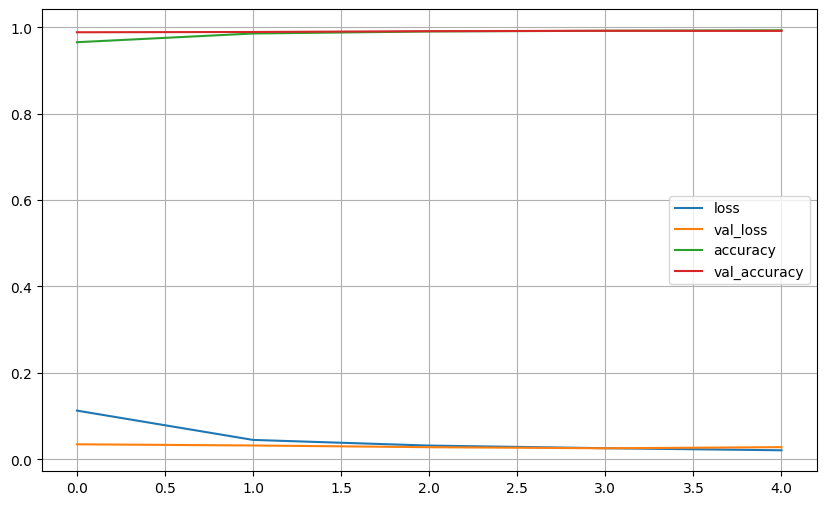

In [6]:
# Metrics
import matplotlib.pyplot as plt

plot_target = ['loss', 'val_loss', 'accuracy', 'val_accuracy']

plt.figure(figsize=(10, 6))

for metric in plot_target:
    plt.plot(hist.history[metric], label=metric)

plt.legend()
plt.grid()
plt.show()

In [7]:
# Evaluate
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9899 - loss: 0.0346


[0.028082648292183876, 0.991599977016449]

In [8]:
# 실제값과 예측값 비교
import numpy as np

predicted_result = model.predict(x_test)
predicted_labels = np.argmax(predicted_result, axis=1)

print(f'Predicted: {predicted_labels[:10]}')
print(f'Real: {y_test[:10]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Predicted: [7 2 1 0 4 1 4 9 5 9]
Real: [7 2 1 0 4 1 4 9 5 9]


In [9]:
# 틀린 데이터
wrong_result = []

for i in range(len(y_test)):
    if predicted_labels[i] != y_test[i]:
        wrong_result.append(i)

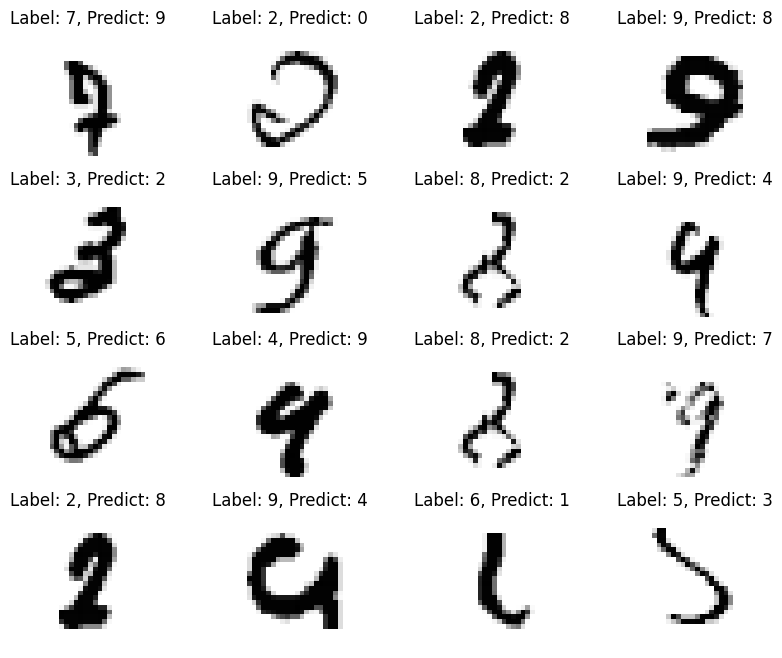

In [10]:
# 틀린 데이터 시각화
import random

samples = random.choices(population=wrong_result, k=16)

plt.figure(figsize=(10, 8))

for idx, i in enumerate(samples):
    plt.subplot(4, 4, idx + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='Greys')
    plt.title(f'Label: {y_test[i]}, Predict: {predicted_labels[i]}')
    plt.axis('off')
plt.show()

In [ ]:
# Model save
model.save('mnist_cnn.h5')

In [20]:
# Fashion MNIST Dataset Load
from tensorflow.keras import datasets

mnist = datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 정규화
x_train, x_test = x_train / 255.0, x_test / 255.0

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
# Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout

model = Sequential([
    Conv2D(32,
           kernel_size=(5, 5),
           strides=(1, 1),
           padding='same',
           activation='relu',
           input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2),
              strides=(2, 2)),
    Conv2D(64,
           kernel_size=(2, 2),
           strides=(1, 1),
           padding='same',
           activation='relu'),
    MaxPooling2D((2, 2),
                 strides=(2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(1000,
          activation='relu'),
    Dense(10,
          activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1000)           │     3,137,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,156,098 (12.04 MB)

 Trainable params: 3,156,098 (12.04 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
hist = model.fit(x_train,
                 y_train,
                 epochs=5,
                 validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 148s 78ms/step - accuracy: 0.8034 - loss: 0.5343 - val_accuracy: 0.8888 - val_loss: 0.3068
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 198s 76ms/step - accuracy: 0.8960 - loss: 0.2781 - val_accuracy: 0.9011 - val_loss: 0.2703
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 211s 81ms/step - accuracy: 0.9127 - loss: 0.2290 - val_accuracy: 0.9090 - val_loss: 0.2499
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 198s 79ms/step - accuracy: 0.9256 - loss: 0.1975 - val_accuracy: 0.9155 - val_loss: 0.2317
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 146s 78ms/step - accuracy: 0.9374 - loss: 0.1691 - val_accuracy: 0.9171 - val_loss: 0.2397


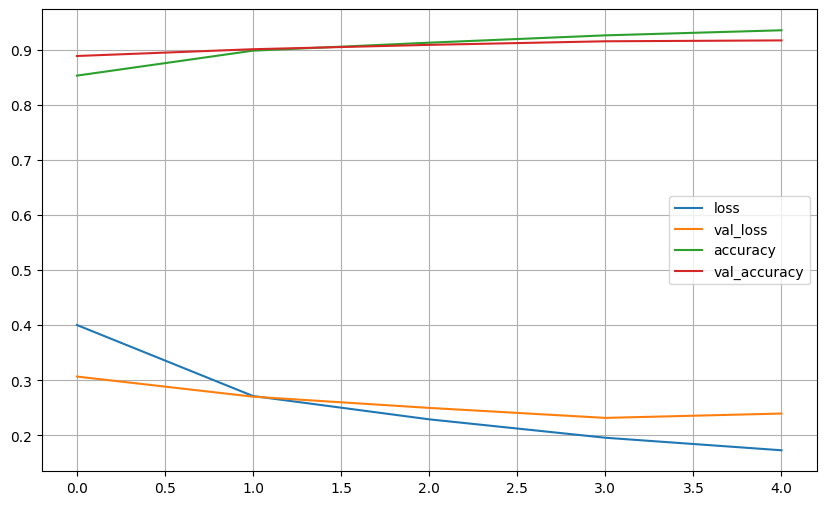

In [23]:
# Metrics
import matplotlib.pyplot as plt

plot_target = ['loss', 'val_loss', 'accuracy', 'val_accuracy']

plt.figure(figsize=(10, 6))

for metric in plot_target:
    plt.plot(hist.history[metric], label=metric)

plt.legend()
plt.grid()
plt.show()

In [24]:
# Evaluate
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9171 - loss: 0.2446


[0.23966899514198303, 0.9171000123023987]

In [25]:
# 실제값과 예측값 비교
import numpy as np

predicted_result = model.predict(x_test)
predicted_labels = np.argmax(predicted_result, axis=1)

print(f'Predicted: {predicted_labels[:10]}')
print(f'Real: {y_test[:10]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Predicted: [9 2 1 1 6 1 4 6 5 7]
Real: [9 2 1 1 6 1 4 6 5 7]


In [26]:
# 틀린 데이터 개수
wrong_result = []

for i in range(len(y_test)):
    if predicted_labels[i] != y_test[i]:
        wrong_result.append(i)
len(wrong_result)

829

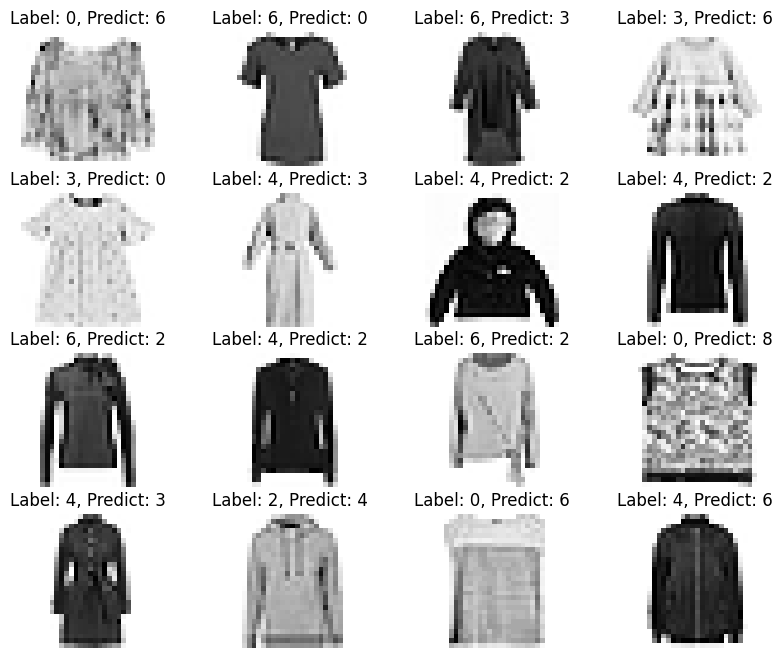

In [27]:
# 틀린 데이터 시각화
import random

samples = random.choices(population=wrong_result, k=16)

plt.figure(figsize=(10, 8))

for idx, i in enumerate(samples):
    plt.subplot(4, 4, idx + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='Greys')
    plt.title(f'Label: {y_test[i]}, Predict: {predicted_labels[i]}')
    plt.axis('off')
plt.show()

In [ ]:
# Model save
model.save('fashion_mnist_cnn.h5')